# Baseline CNN 🚀

### Imports

In [1]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm import tqdm

### Configuration

In [22]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", DEVICE)

TRAIN_DIR = "../data/raw/Lung_Disease_Dataset/train"
VAL_DIR = "../data/raw/Lung_Disease_Dataset/val"
TEST_DIR = "../data/raw/Lung_Disease_Dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 30
LEARNING_RATE = 1e-3

NUM_CLASSES= 5

MODEL_SAVE_PATH = "../models/Baseline/baseline_cnn_best.pth"
HISTORY_SAVE_PATH = "../models/Baseline/baseline_cnn_history.csv"

Using Device: cuda


### Transforms

In [12]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Dataset & DataLoaders

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
Train: 6054
Val: 2016
Test: 2025


### Class Weights

In [5]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print(class_weights)

tensor([1.0048, 0.9941, 1.0031, 0.9925, 1.0056], device='cuda:0')


### Baseline CNN

In [6]:
import torch.nn as nn

class BaselineCNN(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)

        return x

### Initialize Model

In [10]:
NUM_CLASSES = len(train_dataset.classes)

print("Classes:", train_dataset.classes)
print("Number of Classes:", NUM_CLASSES)

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
Number of Classes: 5


In [11]:
model = BaselineCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

### Loss & Optimizer

In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

### Imports for Metrics

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from copy import deepcopy
import pandas as pd

### Training Function

In [15]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, accuracy, precision, recall, f1

### Validation Function


In [16]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1
    )

### Scheduler + Early Stopping

In [17]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

EARLY_STOPPING_PATIENCE = 15

best_val_loss = float("inf")
early_stop_counter = 0

best_model_weights = deepcopy(model.state_dict())

### History

In [18]:
history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": []
}

In [ ]:
'''

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc, val_prec, val_rec, val_f1 = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    history["train_recall"].append(train_rec)
    history["val_recall"].append(val_rec)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Train Recall: {train_rec:.4f} | "
        f"Val Recall: {val_rec:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_weights = deepcopy(
            model.state_dict()
        )

        torch.save(
            model.state_dict(),
            "best_baseline_cnn.pth"
        )

        early_stop_counter = 0

        print("★ Model Saved")

    else:

        early_stop_counter += 1

        print(
            f"Early Stopping Counter: "
            f"{early_stop_counter}/{EARLY_STOPPING_PATIENCE}"
        )

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n★ Early Stopping Triggered")
        break


    '''


Epoch [1/30]
Train Loss: 0.9770 | Val Loss: 0.8916
Train Recall: 0.5941 | Val Recall: 0.6180
★ Model Saved

Epoch [2/30]
Train Loss: 0.7307 | Val Loss: 0.9483
Train Recall: 0.6921 | Val Recall: 0.6551
Early Stopping Counter: 1/15

Epoch [3/30]
Train Loss: 0.6776 | Val Loss: 1.3826
Train Recall: 0.7090 | Val Recall: 0.5255
Early Stopping Counter: 2/15

Epoch [4/30]
Train Loss: 0.6353 | Val Loss: 0.6878
Train Recall: 0.7313 | Val Recall: 0.6863
★ Model Saved

Epoch [5/30]
Train Loss: 0.6084 | Val Loss: 0.6453
Train Recall: 0.7402 | Val Recall: 0.7357
★ Model Saved

Epoch [6/30]
Train Loss: 0.5772 | Val Loss: 0.6156
Train Recall: 0.7523 | Val Recall: 0.7366
★ Model Saved

Epoch [7/30]
Train Loss: 0.5658 | Val Loss: 0.5807
Train Recall: 0.7596 | Val Recall: 0.7518
★ Model Saved

Epoch [8/30]
Train Loss: 0.5749 | Val Loss: 0.7265
Train Recall: 0.7626 | Val Recall: 0.7128
Early Stopping Counter: 1/15

Epoch [9/30]
Train Loss: 0.5508 | Val Loss: 0.5501
Train Recall: 0.7660 | Val Recall: 0.77

In [20]:
import os

print(os.path.exists("../models"))
print(MODEL_SAVE_PATH)

True
../models/baseline_cnn_best.pth


In [21]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    HISTORY_SAVE_PATH,
    index=False
)

print(f"History saved to: {HISTORY_SAVE_PATH}")

History saved to: ../models/baseline_cnn_history.csv


## Reports


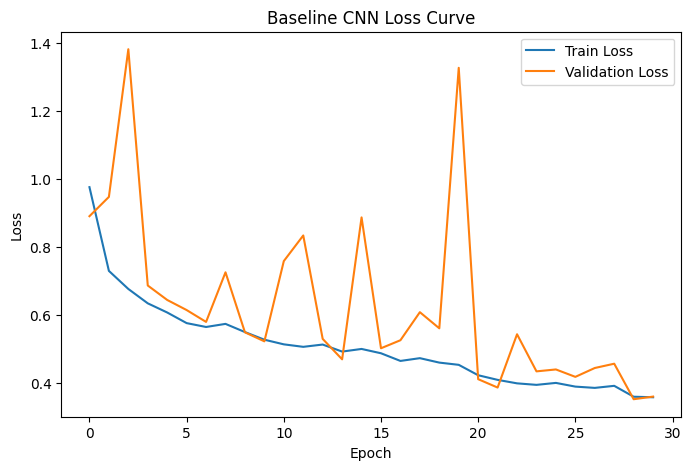

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss Curve")
plt.legend()

plt.savefig(
    "../models/Baseline/loss_curve.png",
    bbox_inches="tight"
)

plt.show()

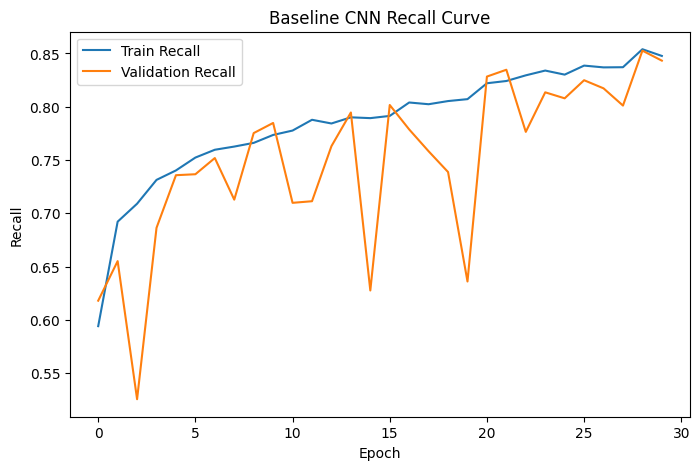

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history["train_recall"], label="Train Recall")
plt.plot(history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Baseline CNN Recall Curve")
plt.legend()

plt.savefig(
    "../models/Baseline/recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [30]:
class_names = train_dataset.classes

print(class_names)

['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


In [31]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names
)

print(report)

with open(
    "../models/Baseline/classification_report.txt",
    "w"
) as f:
    f.write(report)

                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.76      0.69      0.72       403
Corona Virus Disease       0.97      0.95      0.96       407
              Normal       0.89      0.94      0.91       404
        Tuberculosis       0.97      0.98      0.98       408
     Viral Pneumonia       0.66      0.69      0.67       403

            accuracy                           0.85      2025
           macro avg       0.85      0.85      0.85      2025
        weighted avg       0.85      0.85      0.85      2025



In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_acc = accuracy_score(
    all_labels,
    all_preds
)

test_precision = precision_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

Accuracy  : 0.8509
Precision : 0.8503
Recall    : 0.8503
F1 Score  : 0.8497


In [35]:
with open(
    "../models/Baseline/metrics.txt",
    "w"
) as f:

    f.write(f"Accuracy  : {test_acc:.4f}\n")
    f.write(f"Precision : {test_precision:.4f}\n")
    f.write(f"Recall    : {test_recall:.4f}\n")
    f.write(f"F1 Score  : {test_f1:.4f}\n")

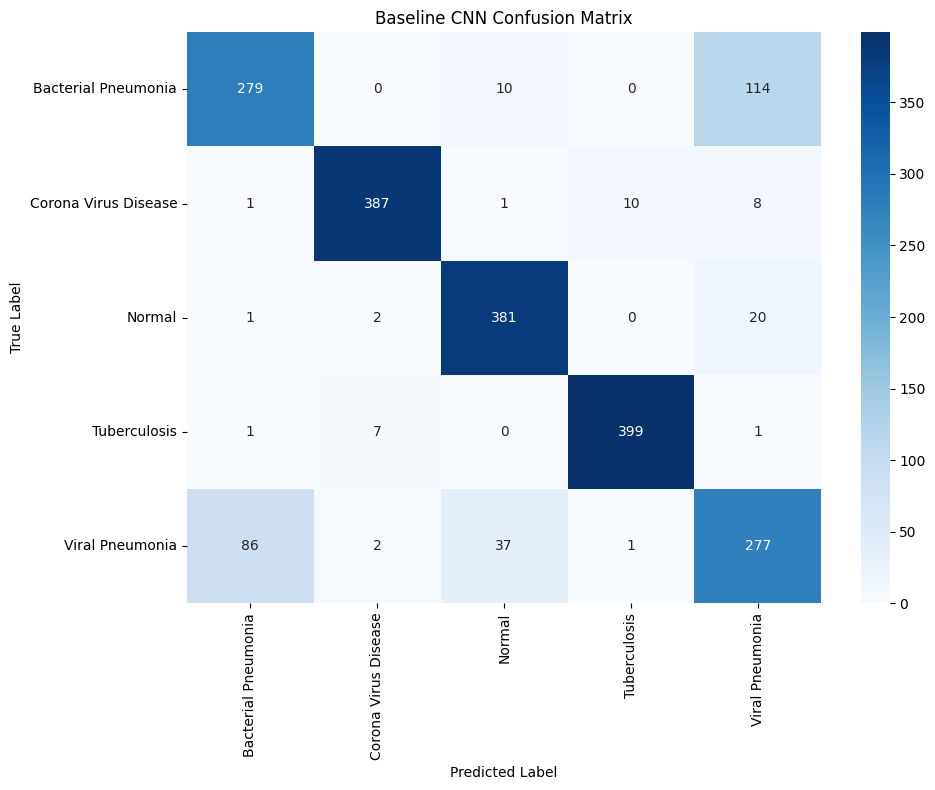

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "../models/Baseline/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()